In [3]:
import os, time
print("PID:", os.getpid(), "time:", time.ctime())
import warnings
warnings.filterwarnings("ignore")

PID: 18612 time: Thu Jan  1 00:39:32 2026


In [4]:
import os, warnings, logging
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore")

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

In [5]:
import os, re, math, random
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [6]:
from pathlib import Path
import os

BASE_DIR = Path(r"C:\Users\olesia\Desktop\1s\ad\lab4")
if BASE_DIR.exists():
    os.chdir(BASE_DIR)
print("cwd:", Path.cwd())

try:
    from huggingface_hub import HfFolder
    for k in ["HF_TOKEN", "HUGGINGFACEHUB_API_TOKEN", "HF_HUB_TOKEN", "HUGGINGFACE_TOKEN"]:
        os.environ.pop(k, None)
    try:
        HfFolder.delete_token()
    except Exception:
        pass
except Exception:
    pass

cwd: C:\Users\olesia\Desktop\1s\ad\lab4


In [7]:
data_dir = Path("data_manythings")
candidates = [
    data_dir / "ukr.txt",
    data_dir / "ukr-eng" / "ukr.txt",
    data_dir / "ukr-eng.txt",
]
txt_path = next((p for p in candidates if p.exists()), None)
if txt_path is None:
    raise FileNotFoundError("Put ManyThings file to data_manythings/ukr.txt")
lines = txt_path.read_text(encoding="utf-8").splitlines()
pairs = []
for l in lines:
    parts = l.split("\t")
    if len(parts) >= 2:
        a = parts[0].strip()
        b = parts[1].strip()
        if a and b:
            pairs.append((a, b))
print(txt_path.as_posix(), len(pairs), pairs[0])


data_manythings/ukr.txt 160049 ('Go.', 'Йди.')


In [8]:
def has_cyrillic(s):
    return bool(re.search(r"[А-Яа-яІіЇїЄєҐґ]", s))

sample = random.sample(pairs, k=min(2000, len(pairs)))
c0 = sum(has_cyrillic(p[0]) for p in sample) / len(sample)
c1 = sum(has_cyrillic(p[1]) for p in sample) / len(sample)
if c0 >= c1:
    ukr_eng = [(p[0], p[1]) for p in pairs]
else:
    ukr_eng = [(p[1], p[0]) for p in pairs]
random.shuffle(ukr_eng)
ukr_eng = ukr_eng[:60000]
print(ukr_eng[0])


('Я переклав цей лист на французьку для Тома.', 'I translated the letter into French for Tom.')


In [9]:
MAX_VOCAB = 15000
MAX_LEN_SRC = 20
MAX_LEN_TGT = 20
specials = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]

def tokenize(text):
    return text.lower().strip().split()

def build_vocab(sentences):
    counter = {}
    for s in sentences:
        for w in tokenize(s):
            counter[w] = counter.get(w, 0) + 1
    vocab = specials + [w for w, _ in sorted(counter.items(), key=lambda x: x[1], reverse=True)[: MAX_VOCAB - len(specials)]]
    stoi = {w:i for i,w in enumerate(vocab)}
    itos = vocab
    return stoi, itos

ukr_sent = [p[0] for p in ukr_eng]
eng_sent = [p[1] for p in ukr_eng]

ukr_stoi, ukr_itos = build_vocab(ukr_sent)
eng_stoi, eng_itos = build_vocab(eng_sent)

PAD_IDX = ukr_stoi["[PAD]"]
UNK_IDX = ukr_stoi["[UNK]"]
BOS_IDX = ukr_stoi["[BOS]"]
EOS_IDX = ukr_stoi["[EOS]"]

print(len(ukr_stoi), len(eng_stoi))


15000 13364


In [10]:
def encode(sentence, stoi, max_len, add_specials=True):
    ids = []
    if add_specials:
        ids.append(BOS_IDX)
    for w in tokenize(sentence)[: max_len - (2 if add_specials else 0)]:
        ids.append(stoi.get(w, UNK_IDX))
    if add_specials:
        ids.append(EOS_IDX)
    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

def prepare_pair(src_ukr, tgt_eng):
    src = encode(src_ukr, ukr_stoi, MAX_LEN_SRC, add_specials=True)
    tgt_in = encode(tgt_eng, eng_stoi, MAX_LEN_TGT, add_specials=True)
    tgt_out = tgt_in[1:] + [PAD_IDX]
    return src, tgt_in, tgt_out

class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        src_ukr, tgt_eng = self.pairs[idx]
        src, tgt_in, tgt_out = prepare_pair(src_ukr, tgt_eng)
        return torch.tensor(src), torch.tensor(tgt_in), torch.tensor(tgt_out)

val_size = max(2000, int(0.05 * len(ukr_eng)))
train_pairs = ukr_eng[:-val_size]
val_pairs = ukr_eng[-val_size:]

batch_size = 64
train_loader = DataLoader(TranslationDataset(train_pairs), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TranslationDataset(val_pairs), batch_size=batch_size, shuffle=False)

x = next(iter(train_loader))
print(x[0].shape, x[1].shape, x[2].shape)


torch.Size([64, 20]) torch.Size([64, 20]) torch.Size([64, 20])


In [11]:
def make_padding_mask(x, pad_idx=PAD_IDX):
    return (x == pad_idx)

def generate_subsequent_mask(size, device):
    return torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)

class TokenPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=50, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        b, t = x.shape
        pos = torch.arange(t, device=x.device).unsqueeze(0).expand(b, t)
        return self.dropout(self.token_emb(x) + self.pos_emb(pos))

class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64, n_heads=4, num_layers=2, d_ff=128, max_len_src=20, max_len_tgt=20, dropout=0.1):
        super().__init__()
        self.src_emb = TokenPositionalEmbedding(src_vocab_size, d_model, max_len_src, dropout)
        self.tgt_emb = TokenPositionalEmbedding(tgt_vocab_size, d_model, max_len_tgt, dropout)
        self.transformer = nn.Transformer(d_model=d_model, nhead=n_heads, num_encoder_layers=num_layers, num_decoder_layers=num_layers, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
    def forward(self, src, tgt_in):
        src_key_padding_mask = make_padding_mask(src)
        tgt_key_padding_mask = make_padding_mask(tgt_in)
        tgt_mask = generate_subsequent_mask(tgt_in.size(1), tgt_in.device)
        src_emb = self.src_emb(src)
        tgt_emb = self.tgt_emb(tgt_in)
        out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask, src_key_padding_mask=src_key_padding_mask, tgt_key_padding_mask=tgt_key_padding_mask, memory_key_padding_mask=src_key_padding_mask)
        return self.fc_out(out)

model = Seq2SeqTransformer(len(ukr_stoi), len(eng_stoi), d_model=64, n_heads=4, num_layers=2, d_ff=128, max_len_src=MAX_LEN_SRC, max_len_tgt=MAX_LEN_TGT).to(device)
print(sum(p.numel() for p in model.parameters()))


2854196


In [12]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    total_tokens = 0
    for src, tgt_in, tgt_out in loader:
        src = src.to(device)
        tgt_in = tgt_in.to(device)
        tgt_out = tgt_out.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(src, tgt_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        n = (tgt_out != PAD_IDX).sum().item()
        total_loss += loss.item() * n
        total_tokens += n
    return total_loss / max(1, total_tokens)

EPOCHS = 6
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    vl = run_epoch(val_loader, False)
    print(ep, tr, vl)


1 5.599947882533051 4.619239857422449
2 4.448865022003845 4.105403859256722
3 4.0474420755551765 3.7968790946728928
4 3.7703476303994146 3.5776951875392053
5 3.557020825658088 3.4180451543316073
6 3.378143424303457 3.267876057992071


In [13]:
def decode(ids, itos):
    out = []
    for i in ids:
        if i == EOS_IDX:
            break
        if i == PAD_IDX or i == BOS_IDX:
            continue
        if 0 <= i < len(itos):
            out.append(itos[i])
    return " ".join(out)

@torch.no_grad()
def translate(sentence_ukr, max_len=MAX_LEN_TGT):
    model.eval()
    src = torch.tensor([encode(sentence_ukr, ukr_stoi, MAX_LEN_SRC, add_specials=True)], dtype=torch.long).to(device)
    tgt_ids = [BOS_IDX]
    for _ in range(max_len - 1):
        tgt_in = torch.tensor([tgt_ids + [PAD_IDX] * (MAX_LEN_TGT - len(tgt_ids))], dtype=torch.long).to(device)
        logits = model(src, tgt_in)
        next_id = int(torch.argmax(logits[0, len(tgt_ids) - 1]).item())
        tgt_ids.append(next_id)
        if next_id == EOS_IDX:
            break
    return decode(tgt_ids, eng_itos)

for _ in range(5):
    s, ref = random.choice(ukr_eng)
    print(s)
    print(ref)
    print(translate(s))
    print()


Він показав нам кілька фотографій.
He showed us some pictures.
he has us to be a good idea.

Просто зроби це заради мене.
Humor me.
just do that for me.

Я зараз дуже хочу спати.
I'm very sleepy now.
i just want to be a good

Я не годував собаку.
I didn't feed the dog.
i don't have a lot.

Вони всі туди поїхали.
All of them went there.
they all my new car.



In [14]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

root = Path("./data")
batch_size = 128
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root=str(root), train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root=str(root), train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

x0, _ = next(iter(train_loader))
print("train batch:", x0.shape)

cpu
train batch: torch.Size([128, 1, 28, 28])


In [15]:
original_dim = 28 * 28
intermediate_dim = 512
latent_dim = 2
epochs = 15

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
    def forward(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mean(h), self.fc_logvar(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    def forward(self, z):
        h = F.relu(self.fc1(z))
        return torch.sigmoid(self.fc2(h))

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std
    def forward(self, x):
        mean, logvar = self.encoder(x)
        z = self.reparameterize(mean, logvar)
        recon = self.decoder(z)
        return recon, mean, logvar

def loss_fn(x_recon, x, z_mean, z_logvar):
    recon = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp(), dim=1).mean()
    return recon + kl

vae = VAE(original_dim, intermediate_dim, latent_dim).to(device)
opt = optim.Adam(vae.parameters(), lr=1e-3)
print(sum(p.numel() for p in vae.parameters()))


807700


In [16]:
def train_vae_epoch():
    vae.train()
    total = 0.0
    for x, _ in train_loader:
        x = x.to(device).view(x.size(0), -1)
        opt.zero_grad()
        x_recon, z_mean, z_logvar = vae(x)
        loss = loss_fn(x_recon, x, z_mean, z_logvar)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    return total / len(train_loader.dataset)

for e in range(1, epochs + 1):
    l = train_vae_epoch()
    print(e, l)


1 292.4095108886719
2 272.55003955078126
3 269.53683037109374
4 267.65937158203127
5 266.3151044270833
6 265.2425248209635
7 264.6403812825521
8 263.9700204752604
9 263.6446728841146
10 263.18238987630207
11 262.7735707519531
12 262.54591595052085
13 262.28311313476564
14 262.00422451171875
15 261.8141282389323


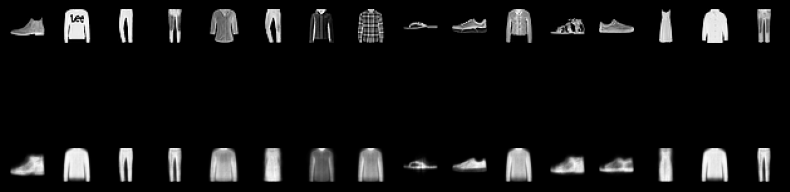

In [17]:
vae.eval()
x, _ = next(iter(test_loader))
x = x.to(device)[:16]
x_flat = x.view(x.size(0), -1)
with torch.no_grad():
    x_recon, _, _ = vae(x_flat)
x_recon = x_recon.view(-1, 1, 28, 28).cpu().numpy()
x = x.cpu().numpy()

plt.figure(figsize=(8,4))
for i in range(16):
    plt.subplot(2, 16, i + 1)
    plt.imshow(x[i,0], cmap="gray")
    plt.axis("off")
    plt.subplot(2, 16, 16 + i + 1)
    plt.imshow(x_recon[i,0], cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()


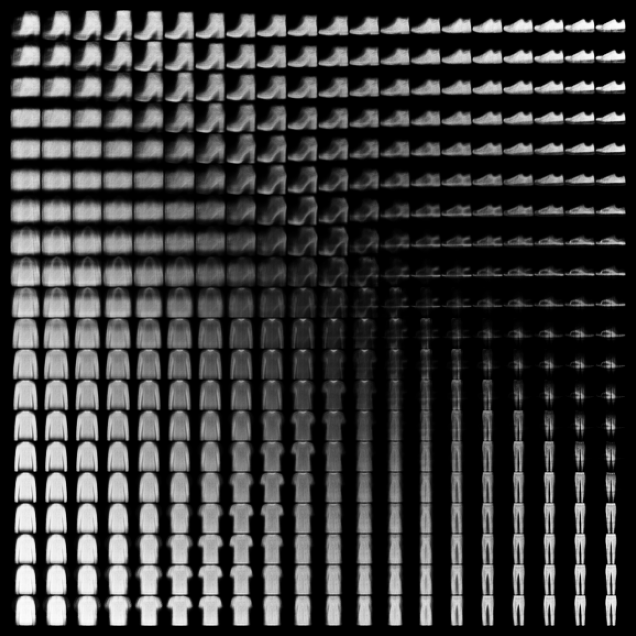

In [18]:
vae.eval()
n = 20
img_size = 28
grid = np.zeros((img_size * n, img_size * n))
lin = np.linspace(-2, 2, n)
with torch.no_grad():
    for i, yi in enumerate(lin):
        for j, xi in enumerate(lin):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_gen = vae.decoder(z).view(img_size, img_size).cpu().numpy()
            grid[i*img_size:(i+1)*img_size, j*img_size:(j+1)*img_size] = x_gen
plt.figure(figsize=(8,8))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.show()


In [19]:
from pathlib import Path
for p in [Path("spam.csv"), Path("data/spam.csv"), Path("data/text_cls.csv"), Path("data/texts.csv")]:
    if p.exists():
        print("USING FILE:", p.resolve())
        break

USING FILE: C:\Users\olesia\Desktop\1s\ad\lab4\spam.csv


In [20]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM, pipeline

df_path = None
for p in [Path("spam.csv"), Path("data/text_cls.csv")]:
    if p.exists():
        df_path = p
        break
if df_path is None:
    raise FileNotFoundError("Put dataset into spam.csv or data/text_cls.csv")

if df_path.name.lower() == "spam.csv":
    df = pd.read_csv(df_path, encoding="latin-1")
    df = df.rename(columns={"v1":"label","v2":"text"})
    df = df[["text","label"]]
else:
    df = pd.read_csv(df_path)
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError("CSV must contain text,label")
    df = df[["text","label"]]

df = df.dropna().reset_index(drop=True)
print(df_path.as_posix(), df.shape)
print(df.head())


spam.csv (5572, 2)
                                                text label
0  Go until jurong point, crazy.. Available only ...   ham
1                      Ok lar... Joking wif u oni...   ham
2  Free entry in 2 a wkly comp to win FA Cup fina...  spam
3  U dun say so early hor... U c already then say...   ham
4  Nah I don't think he goes to usf, he lives aro...   ham


In [21]:
import sys
from pathlib import Path

try:
    import sentencepiece  # noqa: F401
except Exception:
    !"{sys.executable}" -m pip install -q sentencepiece

models_root = Path("models")
MODEL_ID = {
    "spam_1": "mrm8488/bert-tiny-finetuned-sms-spam-detection",
    "spam_2": "mariagrandury/distilbert-base-uncased-finetuned-sms-spam-detection",
    "zs_1": "joeddav/xlm-roberta-large-xnli",
    "zs_2": "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    "summ": "ukr-models/uk-summarizer",
    "uk_en": "Helsinki-NLP/opus-mt-uk-en",
    "en_uk": "Helsinki-NLP/opus-mt-en-uk",
}

MODEL_DIR = {
    "spam_1": models_root / "bert-tiny-sms-spam",
    "spam_2": models_root / "distilbert-sms-spam",
    "zs_1": models_root / "xlm-roberta-large-xnli",
    "zs_2": models_root / "mdeberta-v3-base-mnli-xnli",
    "summ": models_root / "uk-summarizer",
    "uk_en": models_root / "opus-mt-uk-en",
    "en_uk": models_root / "opus-mt-en-uk",
}
models_root.mkdir(parents=True, exist_ok=True)

def model_ref(key: str):
    p = MODEL_DIR.get(key)
    if p is not None and p.exists():
        return str(p), True
    return MODEL_ID[key], False

present = [k for k, v in MODEL_DIR.items() if v.exists()]
missing = [k for k, v in MODEL_DIR.items() if not v.exists()]
print("Local HF models present:", present)
print("Missing (will download from Hugging Face on first use):", missing)

Local HF models present: ['spam_1', 'spam_2', 'zs_1', 'zs_2', 'summ', 'uk_en', 'en_uk']
Missing (will download from Hugging Face on first use): []


In [22]:
texts = df["text"].astype(str).tolist()
y_true = df["label"].astype(str).str.lower().tolist()
labels = sorted(set(y_true))
use_spam_models = set(labels) == {"ham", "spam"}

device_id = 0 if torch.cuda.is_available() else -1

if use_spam_models:
    m1, local1 = model_ref("spam_1")
    tok1 = AutoTokenizer.from_pretrained(m1, use_fast=False, local_files_only=local1, token=False)
    mod1 = AutoModelForSequenceClassification.from_pretrained(m1, local_files_only=local1, token=False)

    m2, local2 = model_ref("spam_2")
    tok2 = AutoTokenizer.from_pretrained(m2, use_fast=False, local_files_only=local2, token=False)
    mod2 = AutoModelForSequenceClassification.from_pretrained(m2, local_files_only=local2, token=False)

    p1 = pipeline("text-classification", model=mod1, tokenizer=tok1, truncation=True, device=device_id)
    p2 = pipeline("text-classification", model=mod2, tokenizer=tok2, truncation=True, device=device_id)

    def norm_spam(l):
        s = str(l).lower()
        if "spam" in s:
            return "spam"
        if "ham" in s or "not_spam" in s or "not spam" in s:
            return "ham"
        if s in {"label_0", "0"}:
            return "ham"
        if s in {"label_1", "1"}:
            return "spam"
        return s

    r1 = p1(texts, batch_size=32)
    r2 = p2(texts, batch_size=32)
    y1 = [norm_spam(x["label"]) for x in r1]
    y2 = [norm_spam(x["label"]) for x in r2]

else:
    cands = labels

    mzs1, lzs1 = model_ref("zs_1")
    tok1 = AutoTokenizer.from_pretrained(mzs1, use_fast=False, local_files_only=lzs1, token=False)
    mod1 = AutoModelForSequenceClassification.from_pretrained(mzs1, local_files_only=lzs1, token=False)

    mzs2, lzs2 = model_ref("zs_2")
    tok2 = AutoTokenizer.from_pretrained(mzs2, use_fast=False, local_files_only=lzs2, token=False)
    mod2 = AutoModelForSequenceClassification.from_pretrained(mzs2, local_files_only=lzs2, token=False)

    p1 = pipeline("zero-shot-classification", model=mod1, tokenizer=tok1, device=device_id)
    p2 = pipeline("zero-shot-classification", model=mod2, tokenizer=tok2, device=device_id)

    def zs_pred(pipe, t):
        o = pipe(t, cands, hypothesis_template="This text is about {}.")
        return o["labels"][0], o

    y1, y2, r1, r2 = [], [], [], []
    for t in texts:
        a, oa = zs_pred(p1, t)
        b, ob = zs_pred(p2, t)
        y1.append(a); r1.append(oa)
        y2.append(b); r2.append(ob)

acc1 = accuracy_score(y_true, y1)
acc2 = accuracy_score(y_true, y2)
print("acc_1 =", acc1)
print("acc_2 =", acc2)
print(classification_report(y_true, y1))
print(classification_report(y_true, y2))

out = pd.DataFrame({"text": texts, "label_true": y_true, "pred_1": y1, "pred_2": y2})
out.to_csv((Path.cwd() / "out_hf_text_classification_results.csv").as_posix(), index=False, encoding="utf-8")
out.head()

acc_1 = 0.9847451543431442
acc_2 = 0.9958722182340273
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      4825
        spam       0.97      0.91      0.94       747

    accuracy                           0.98      5572
   macro avg       0.98      0.95      0.97      5572
weighted avg       0.98      0.98      0.98      5572

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00      4825
        spam       1.00      0.97      0.98       747

    accuracy                           1.00      5572
   macro avg       1.00      0.99      0.99      5572
weighted avg       1.00      1.00      1.00      5572



,text,label_true,pred_1,pred_2
0,"Go until jurong point, crazy.. Available only ...",ham,ham,ham
1,Ok lar... Joking wif u oni...,ham,ham,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,spam,spam
3,U dun say so early hor... U c already then say...,ham,ham,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham,ham,ham


In [23]:
mzs1, lzs1 = model_ref("zs_1")
zs_tok = AutoTokenizer.from_pretrained(mzs1, use_fast=False, local_files_only=lzs1, token=False)
zs_mod = AutoModelForSequenceClassification.from_pretrained(mzs1, local_files_only=lzs1, token=False)
zs = pipeline("zero-shot-classification", model=zs_mod, tokenizer=zs_tok, device=device_id)

text_ua = "Компанія впровадила двофакторну автентифікацію та обов'язкове навчання з кібербезпеки для співробітників."
labs = ["кібербезпека", "фінанси", "спорт", "освіта"]
print(zs(text_ua, labs, hypothesis_template="Це текст про {}.")["labels"][:2])

ms, ls = model_ref("summ")
s_tok = AutoTokenizer.from_pretrained(ms, use_fast=False, local_files_only=ls, token=False)
s_mod = AutoModelForSeq2SeqLM.from_pretrained(ms, local_files_only=ls, token=False)
summ = pipeline("summarization", model=s_mod, tokenizer=s_tok, device=device_id)

long_ua = "В останні роки цифрові сервіси активно розвиваються, але разом із цим зростають і кіберзагрози. Регулярні оновлення, резервні копії та навчання з кібербезпеки знижують ризик витоку даних і простоїв критичних систем."
print(summ(long_ua, max_length=80, min_length=25, do_sample=False)[0]["summary_text"])

mue, lue = model_ref("uk_en")
uk_en_tok = AutoTokenizer.from_pretrained(mue, use_fast=False, local_files_only=lue, token=False)
uk_en_mod = AutoModelForSeq2SeqLM.from_pretrained(mue, local_files_only=lue, token=False)

meu, leu = model_ref("en_uk")
en_uk_tok = AutoTokenizer.from_pretrained(meu, use_fast=False, local_files_only=leu, token=False)
en_uk_mod = AutoModelForSeq2SeqLM.from_pretrained(meu, local_files_only=leu, token=False)

tr_uk_en = pipeline("translation", model=uk_en_mod, tokenizer=uk_en_tok, device=device_id)
tr_en_uk = pipeline("translation", model=en_uk_mod, tokenizer=en_uk_tok, device=device_id)

print(tr_uk_en("Мені потрібен короткий переклад цього речення на англійську.")[0]["translation_text"])
print(tr_en_uk("I need a short translation of this sentence into Ukrainian.")[0]["translation_text"])

['кібербезпека', 'освіта']
Кібербезпека - одна з найбільших у світі технологій, які здатні знизити ризик витоку даних і простоїв критичних систем.
I need a short translation of this sentence into English.
Мені потрібен короткий переклад цього речення на українську мову.
